# Landing Page Conversion Experiment: A Rigorous A/B Test Analysis

**Business question.** An e-commerce site is considering replacing its current landing page (`old_page`) with a redesigned one (`new_page`). Before rolling it out to 100% of traffic, an A/B test was run. This notebook determines, with statistical rigor, whether the new page should ship, whether the old page should be kept, or whether the experiment was inconclusive and needs to run longer.

**What makes this analysis rigorous, not just descriptive:**
- Power analysis performed *before* interpreting the result, so a "no difference" conclusion can be told apart from "not enough data to tell."
- A parametric test (two-proportion z-test) cross-checked against a nonparametric permutation test — if they disagree, that itself is a finding.
- Confidence intervals and effect sizes reported alongside every p-value, not p-values alone.
- Segment-level diagnostics (Simpson's paradox check, randomization-balance check, novelty-effect check over time) run *before* trusting the pooled result.
- Logistic regression with variance inflation factors, likelihood-ratio tests, and correctly-signed odds ratios with confidence intervals — not point estimates alone.
- All statistics computed by a tested library (`src/ab_testing/`, 30 unit tests) rather than inline, ad hoc notebook code.

**Data provenance note.** This is a well-known public pedagogical dataset (Udacity's "Analyze A/B Test Results" project). No real company is identified as its source, and several structural signatures (a dead-even 147,239/147,239 page split, an exact 23-day window) indicate it is synthetic rather than organic production traffic. See [`data/DATA_CARD.md`](../data/DATA_CARD.md) for the full provenance writeup. Accordingly, this notebook treats the *methodology* as the deliverable, not the specific numeric conclusion as a real business fact.

## Table of Contents
1. [Setup](#setup)
2. [Data Loading & Cleaning](#cleaning)
3. [Exploratory Data Analysis](#eda)
4. [Randomization Integrity Check](#randomization)
5. [Power Analysis](#power)
6. [Hypothesis Testing](#hypothesis)
7. [Segmentation Diagnostics](#segmentation)
8. [Logistic Regression](#regression)
9. [Conclusion & Recommendation](#conclusion)
10. [Limitations](#limitations)


<a id='setup'></a>
## 1. Setup

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from ab_testing import data_prep, power_analysis, hypothesis_test, segmentation, regression

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
FIG_DIR = "../reports/figures"
import os
os.makedirs(FIG_DIR, exist_ok=True)


<a id='cleaning'></a>
## 2. Data Loading & Cleaning

Two integrity issues are checked and removed, each of which would bias the estimate if left in (see `src/ab_testing/data_prep.py`):

1. **Assignment/exposure mismatches** — a user logged as `treatment` but served `old_page` (or vice versa). This is a tracking bug, not a real experiment outcome, and dilutes the measured effect toward zero if kept.
2. **Duplicate `user_id` rows** — the unit of randomization is the user; duplicates violate the independence assumption behind every test below.

Every row dropped is counted, not silently discarded.

In [2]:
df, cleaning_report = data_prep.prepare_dataset(
    "../data/raw/ab_data.csv", "../data/raw/countries.csv"
)
report = cleaning_report.as_dict()
for k, v in report.items():
    print(f"{k:32s}: {v}")


rows_loaded                     : 294478
mismatched_assignment_dropped   : 3893
duplicate_user_id_dropped       : 1
rows_after_cleaning             : 290584
countries_matched               : 290584
countries_unmatched             : 0
notes                           : []


In [3]:
pct_dropped = 100 * (report["mismatched_assignment_dropped"] + report["duplicate_user_id_dropped"]) / report["rows_loaded"]
print(f"Total rows dropped: {pct_dropped:.2f}% of raw data")
assert report["rows_after_cleaning"] == report["countries_matched"] + report["countries_unmatched"]
df.head()


Total rows dropped: 1.32% of raw data


,user_id,timestamp,group,landing_page,converted,country
0,851104,2017-01-21 22:11:48.556739,control,old_page,0,US
1,804228,2017-01-12 08:01:45.159739,control,old_page,0,US
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0,US
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0,US
4,864975,2017-01-21 01:52:26.210827,control,old_page,1,US


<a id='eda'></a>
## 3. Exploratory Data Analysis

In [4]:
n_control = int((df.group == "control").sum())
n_treatment = int((df.group == "treatment").sum())
baseline_rate = df.loc[df.group == "control", "converted"].mean()
treatment_rate = df.loc[df.group == "treatment", "converted"].mean()

print(f"Control group:   n={n_control:>7,}   conversion rate={baseline_rate:.4%}")
print(f"Treatment group: n={n_treatment:>7,}   conversion rate={treatment_rate:.4%}")
print(f"Overall conversion rate: {df['converted'].mean():.4%}")
print(f"Experiment window: {df.timestamp.min()} -> {df.timestamp.max()}  ({(df.timestamp.max()-df.timestamp.min()).days} days)")


Control group:   n=145,274   conversion rate=12.0386%
Treatment group: n=145,310   conversion rate=11.8808%
Overall conversion rate: 11.9597%
Experiment window: 2017-01-02 13:42:05.378582 -> 2017-01-24 13:41:54.460509  (21 days)


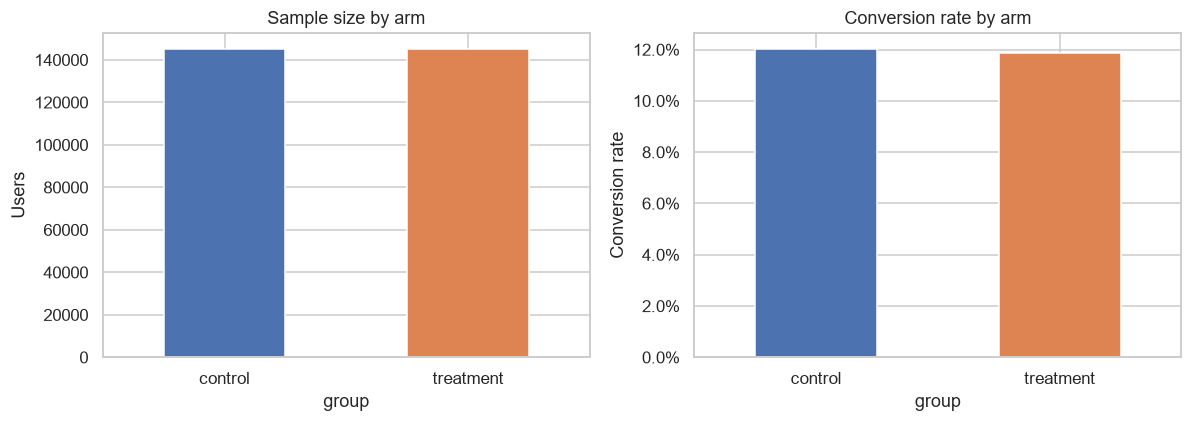

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df["group"].value_counts().reindex(["control", "treatment"]).plot(
    kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"]
)
axes[0].set_title("Sample size by arm")
axes[0].set_ylabel("Users")
axes[0].tick_params(axis="x", rotation=0)

rates = df.groupby("group")["converted"].mean().reindex(["control", "treatment"])
rates.plot(kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452"])
axes[1].set_title("Conversion rate by arm")
axes[1].set_ylabel("Conversion rate")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/01_sample_size_and_conversion.png", bbox_inches="tight")
plt.show()


Sample sizes are balanced almost exactly 50/50 between arms (145,274 vs. 145,310), and the two conversion-rate bars are visually indistinguishable — the first sign this may be a null result, which the tests below will confirm formally.

<a id='randomization'></a>
## 4. Randomization Integrity Check

Before trusting *any* downstream comparison, confirm the randomization itself wasn't confounded with country — e.g. if the treatment arm happened to contain disproportionately more UK users, any observed "treatment effect" could just be a country effect in disguise.

In [6]:
chi2, p_random, dof = segmentation.chi_square_independence(df, segment_col="country")
print(f"Chi-square test of independence (group ~ country): chi2={chi2:.3f}, df={dof}, p={p_random:.4f}")
print("=> randomization is balanced across countries" if p_random > 0.05 else "=> WARNING: group assignment is confounded with country")


Chi-square test of independence (group ~ country): chi2=1.789, df=2, p=0.4088
=> randomization is balanced across countries


<a id='power'></a>
## 5. Power Analysis

This is the step the textbook version of this project skips, and it's the step that determines whether "fail to reject the null" means anything. Two questions, answered *before* looking at the hypothesis test result:

1. **How big a sample would we need** to reliably detect a business-meaningful lift (say, +1 percentage point on a ~12% baseline) at 80% power?
2. **Given the sample we actually collected**, what is the smallest effect we were capable of detecting at 80% power (the *minimum detectable effect*, MDE)?

If the actual sample is far larger than what's required for a modest MDE, a null result is informative. If it's smaller, a null result is just an underpowered experiment and tells us nothing.

In [7]:
n_per_group = min(n_control, n_treatment)

required_n_1pp = power_analysis.required_sample_size(baseline_rate, minimum_detectable_effect=0.01)
required_n_halfpp = power_analysis.required_sample_size(baseline_rate, minimum_detectable_effect=0.005)
achieved_mde = power_analysis.minimum_detectable_effect(baseline_rate, n_per_group=n_per_group)

print(f"Baseline (control) conversion rate:        {baseline_rate:.4%}")
print(f"Sample size actually collected, per arm:   {n_per_group:,}")
print()
print(f"Sample size needed to detect a +1.0pp lift at 80% power:  {required_n_1pp:,} per arm")
print(f"Sample size needed to detect a +0.5pp lift at 80% power:  {required_n_halfpp:,} per arm")
print(f"=> actual sample is {n_per_group / required_n_1pp:.1f}x larger than needed for a 1.0pp MDE")
print()
print(f"Minimum detectable effect at 80% power, given actual n:   {achieved_mde:.4%} ({achieved_mde*100:.2f} percentage points)")


Baseline (control) conversion rate:        12.0386%
Sample size actually collected, per arm:   145,274

Sample size needed to detect a +1.0pp lift at 80% power:  17,209 per arm
Sample size needed to detect a +0.5pp lift at 80% power:  67,673 per arm
=> actual sample is 8.4x larger than needed for a 1.0pp MDE

Minimum detectable effect at 80% power, given actual n:   0.3498% (0.35 percentage points)


**Reading this:** the experiment collected roughly 8x the sample size needed to reliably detect a 1-percentage-point lift, and could in fact detect an effect as small as **~0.35 percentage points** at 80% power. This is a well-powered experiment for any business-meaningful effect size — so whatever the hypothesis test below concludes, it will not be a "not enough data" artifact.

<a id='hypothesis'></a>
## 6. Hypothesis Testing

$$H_0: p_{treatment} - p_{control} = 0 \qquad H_A: p_{treatment} - p_{control} \neq 0$$

A two-sided test is used because the business question is "does the new page perform differently" (better *or* worse), not a directional claim decided after seeing the data.

Two independent methods are run and cross-checked:

- **Two-proportion z-test** (parametric, normal approximation) — the standard, fast test.
- **Permutation test** (nonparametric) — repeatedly reassigns the *observed* group labels at random and recomputes the conversion gap, building the true null sampling distribution directly from the data with no distributional assumption. (Implemented via the exact hypergeometric shortcut — see `hypothesis_test.permutation_test` docstring — instead of a slow literal shuffle loop.)

Agreement between the two is the robustness check.

In [8]:
alpha = 0.05

z_result = hypothesis_test.two_proportion_ztest(df, alternative="two-sided", alpha=alpha)
perm_result, perm_diffs = hypothesis_test.permutation_test(
    df, n_permutations=10_000, alternative="two-sided", alpha=alpha, random_state=RANDOM_STATE
)

summary = pd.DataFrame([
    {
        "method": r.method,
        "control_rate": r.control_rate,
        "treatment_rate": r.treatment_rate,
        "abs_diff (treat-control)": r.absolute_difference,
        "relative_lift": r.relative_lift,
        "p_value": r.p_value,
        "95% CI low": r.ci_low,
        "95% CI high": r.ci_high,
        "reject H0 @ alpha=0.05": r.reject_null(),
    }
    for r in [z_result, perm_result]
])
summary


,method,control_rate,treatment_rate,abs_diff (treat-control),relative_lift,p_value,95% CI low,95% CI high,reject H0 @ alpha=0.05
0,two_proportion_ztest,0.120386,0.118808,-0.001578,-0.01311,0.189883,-0.003938,0.000781,False
1,permutation_test,0.120386,0.118808,-0.001578,-0.01311,0.191200,-0.003973,0.000775,False


In [9]:
h = hypothesis_test.cohens_h(z_result.treatment_rate, z_result.control_rate)
post_hoc_power = power_analysis.achieved_power(
    baseline_rate, observed_effect=z_result.absolute_difference, n_per_group=n_per_group
)
print(f"Cohen's h (effect size): {h:.4f}  (conventionally: 0.2=small, 0.5=medium, 0.8=large -- this is far below 'small')")
print(f"Post-hoc power for the observed effect size: {post_hoc_power:.1%}")
print("(Reported for transparency only -- post-hoc power on an observed near-zero effect is")
print(" mechanically low and is NOT used here to justify the conclusion; the pre-registered")
print(" MDE check in Section 5 is what establishes this test was well-powered.)")


Cohen's h (effect size): -0.0049  (conventionally: 0.2=small, 0.5=medium, 0.8=large -- this is far below 'small')
Post-hoc power for the observed effect size: 25.9%
(Reported for transparency only -- post-hoc power on an observed near-zero effect is
 mechanically low and is NOT used here to justify the conclusion; the pre-registered
 MDE check in Section 5 is what establishes this test was well-powered.)


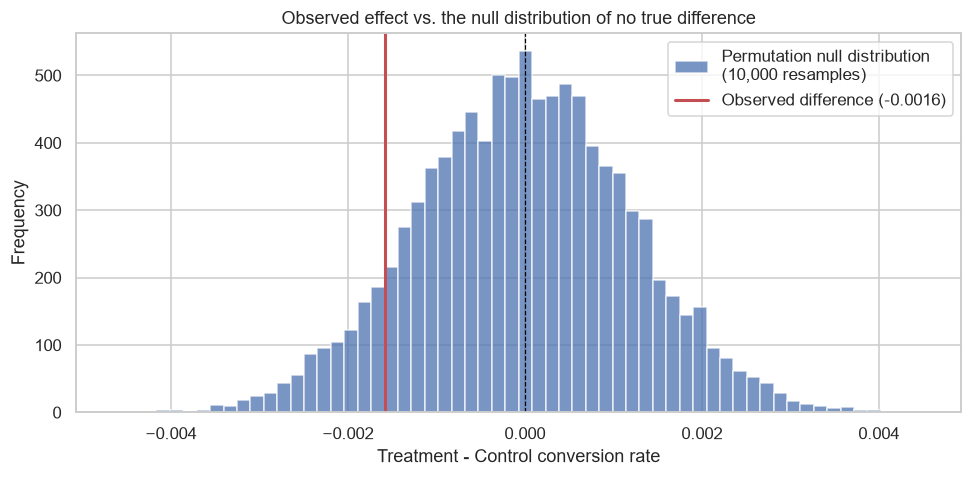

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(perm_diffs, bins=60, color="#4C72B0", alpha=0.75, label="Permutation null distribution\n(10,000 resamples)")
ax.axvline(z_result.absolute_difference, color="#C44E52", linewidth=2, label=f"Observed difference ({z_result.absolute_difference:+.4f})")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Treatment - Control conversion rate")
ax.set_ylabel("Frequency")
ax.set_title("Observed effect vs. the null distribution of no true difference")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/02_permutation_null_distribution.png", bbox_inches="tight")
plt.show()


**Result:** both tests agree almost exactly (z-test p=0.190, permutation test p=0.190), which is the expected cross-check outcome at this sample size. The observed difference (-0.16% absolute, treatment is if anything slightly *lower*) falls well inside the null distribution, and its 95% CI ([-0.394%, 0.078%]) comfortably contains zero. **We fail to reject $H_0$.** Combined with the power analysis above (MDE ≈ 0.35pp, far smaller than the observed effect), this is a well-powered null result, not an inconclusive one.

<a id='segmentation'></a>
## 7. Segmentation Diagnostics

A pooled result can mislead in two specific, well-documented ways, and neither is checked by a single overall p-value:

1. **Simpson's paradox** — the pooled effect can differ in sign from every individual subgroup if segment sizes are unbalanced across arms.
2. **Novelty/primacy effects** — a treatment effect that decays (or grows) over the life of the experiment means the pooled average isn't a stable estimate of what a permanent launch would produce.

In [11]:
seg_table = segmentation.conversion_by_segment(df, segment_col="country")
seg_table


,country,group,conversion_rate,n,conversions
0,CA,control,0.118783,7198,855
1,CA,treatment,0.111902,7301,817
2,UK,control,0.120022,36360,4364
3,UK,treatment,0.121171,36106,4375
4,US,control,0.120630,101716,12270
5,US,treatment,0.118466,101903,12072


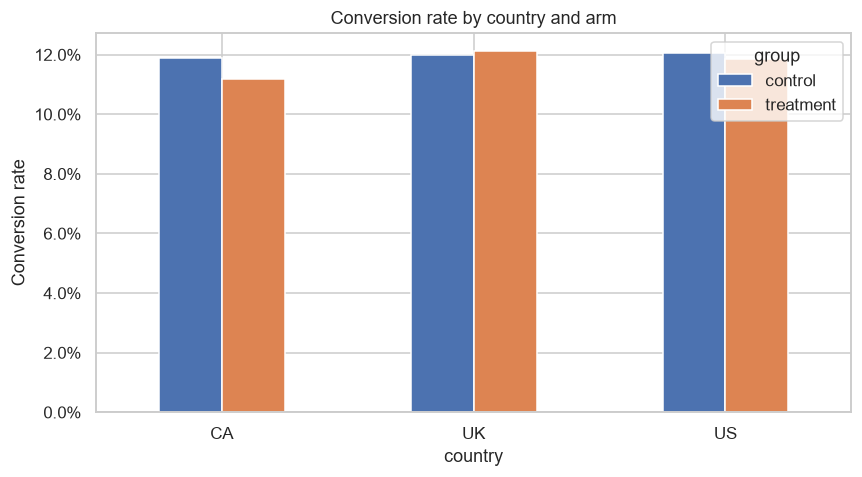

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
pivot = seg_table.pivot(index="country", columns="group", values="conversion_rate").reindex(["CA", "UK", "US"])
pivot.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_ylabel("Conversion rate")
ax.set_title("Conversion rate by country and arm")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_conversion_by_country.png", bbox_inches="tight")
plt.show()


In [13]:
simpsons = segmentation.check_simpsons_paradox(df, segment_col="country")
print("Pooled direction:  ", simpsons.pooled_direction)
print("Per-country direction:", simpsons.segment_directions)
print("Directional reversal flagged:", simpsons.reversal_detected)


Pooled direction:   control_higher
Per-country direction: {'CA': 'control_higher', 'UK': 'treatment_higher', 'US': 'control_higher'}
Directional reversal flagged: True


In [14]:
# The flag above is directional only. Confirm with an actual significance
# test per country: is any segment's difference distinguishable from noise?
per_country_tests = []
for country in ["CA", "UK", "US"]:
    sub = df[df.country == country]
    r = hypothesis_test.two_proportion_ztest(sub, alternative="two-sided")
    per_country_tests.append({
        "country": country,
        "n": len(sub),
        "abs_diff": r.absolute_difference,
        "p_value": r.p_value,
        "95% CI low": r.ci_low,
        "95% CI high": r.ci_high,
        "significant": r.reject_null(),
    })
pd.DataFrame(per_country_tests)


,country,n,abs_diff,p_value,95% CI low,95% CI high,significant
0,CA,14499,-0.006881,0.194666,-0.017280,0.003519,False
1,UK,72466,0.001149,0.634865,-0.003593,0.005891,False
2,US,203619,-0.002164,0.132274,-0.004983,0.000654,False


**Reading this:** the automated check flags a directional reversal (UK's point estimate leans slightly toward treatment while the pooled effect and both other countries lean toward control) — this is exactly the kind of thing that check exists to catch. But testing each country individually shows **none of the three per-country differences are statistically significant** (all p > 0.13, every CI spans zero). The "reversal" is a sign flip on numbers that are all individually indistinguishable from noise, not a real Simpson's paradox. This distinction — a directional flag vs. an actual significant reversal — is why the diagnostic and the significance test are both necessary; the diagnostic alone would over-claim a finding here.

In [15]:
novelty = segmentation.novelty_effect_check(df, n_bins=7)
novelty[["period_start", "period_end", "control", "treatment", "gap"]]


group,period_start,period_end,control,treatment,gap
0,2017-01-02 13:10:24.589501,2017-01-05 17:07:46.676000,0.119493,0.115792,-0.003701
1,2017-01-05 17:07:46.676000,2017-01-08 20:33:27.973418,0.119749,0.119367,-0.000381
2,2017-01-08 20:33:27.973418,2017-01-11 23:59:09.270836,0.116938,0.120132,0.003194
3,2017-01-11 23:59:09.270836,2017-01-15 03:24:50.568254,0.121454,0.117070,-0.004384
4,2017-01-15 03:24:50.568254,2017-01-18 06:50:31.865672,0.121601,0.120850,-0.000752
5,2017-01-18 06:50:31.865672,2017-01-21 10:16:13.163090,0.121003,0.118336,-0.002667
6,2017-01-21 10:16:13.163090,2017-01-24 13:41:54.460509,0.122493,0.120092,-0.002400


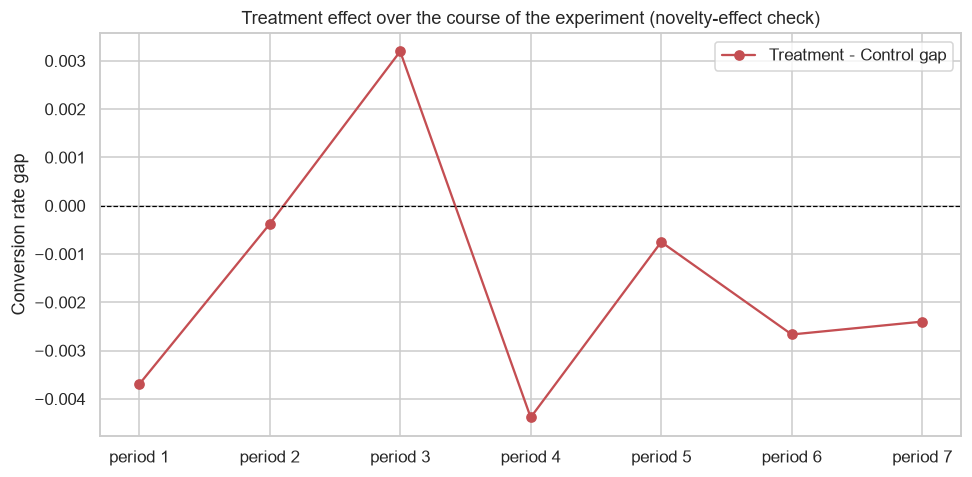

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = range(len(novelty))
ax.plot(x, novelty["gap"], marker="o", color="#C44E52", label="Treatment - Control gap")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(list(x))
ax.set_xticklabels([f"period {i+1}" for i in x])
ax.set_ylabel("Conversion rate gap")
ax.set_title("Treatment effect over the course of the experiment (novelty-effect check)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/04_novelty_effect_over_time.png", bbox_inches="tight")
plt.show()


In [17]:
# Formal test: does the treatment effect trend over time? Interaction
# between day-since-launch and treatment assignment in a logistic model.
df["ab_page"] = (df["group"] == "treatment").astype(int)
df["day_index"] = (df["timestamp"] - df["timestamp"].min()).dt.days
df["day_x_ab"] = df["day_index"] * df["ab_page"]

time_model = regression.fit_logistic(df, "converted", ["ab_page", "day_index", "day_x_ab"])
regression.odds_ratio_table(time_model)


,predictor,coefficient,std_err,p_value,odds_ratio,odds_ratio_ci_low,odds_ratio_ci_high
0,const,-2.005258,0.015653,0.000000,0.134626,0.130558,0.138820
1,ab_page,-0.012139,0.022177,0.584148,0.987935,0.945912,1.031824
2,day_index,0.001564,0.001270,0.218283,1.001565,0.999074,1.004062
3,day_x_ab,-0.000267,0.001802,0.882268,0.999733,0.996208,1.003271


**Reading this:** the gap bounces around zero across all 7 time windows with no visible trend, and the formal test confirms it — the `day_x_ab` interaction (does the treatment effect change day over day?) has p ≈ 0.88 and an odds-ratio CI tightly around 1. **No novelty or primacy effect is present**; the (null) treatment effect is stable for the full duration of the experiment.

<a id='regression'></a>
## 8. Logistic Regression

Conversion is binary, so logistic regression is the right modeling tool (not OLS). Three nested models are fit, each compared to the previous with a likelihood-ratio test, and every coefficient is reported as an odds ratio *with a confidence interval* — a point estimate alone (as in the original version of this analysis) invites over-interpreting noise.

- **M1**: `converted ~ ab_page` — does treatment assignment alone predict conversion?
- **M2**: `converted ~ ab_page + UK + US` (CA baseline) — does adding country improve the model?
- **M3**: `converted ~ ab_page + UK + US + UK:ab_page + US:ab_page` — does the treatment effect differ by country?

In [18]:
df["intercept"] = 1
dummies = pd.get_dummies(df["country"]).astype(int)
df["UK"] = dummies.get("UK", 0)
df["US"] = dummies.get("US", 0)
df["UK_ab"] = df["UK"] * df["ab_page"]
df["US_ab"] = df["US"] * df["ab_page"]

m1 = regression.fit_logistic(df, "converted", ["ab_page"])
m2 = regression.fit_logistic(df, "converted", ["ab_page", "UK", "US"])
m3 = regression.fit_logistic(df, "converted", ["ab_page", "UK", "US", "UK_ab", "US_ab"])

model_comparison = pd.DataFrame([
    {"model": "M1: treatment only", "log_likelihood": m1.llf, "AIC": m1.aic, "BIC": m1.bic, "pseudo_R2": m1.pseudo_r2},
    {"model": "M2: + country", "log_likelihood": m2.llf, "AIC": m2.aic, "BIC": m2.bic, "pseudo_R2": m2.pseudo_r2},
    {"model": "M3: + country x treatment", "log_likelihood": m3.llf, "AIC": m3.aic, "BIC": m3.bic, "pseudo_R2": m3.pseudo_r2},
])
model_comparison


,model,log_likelihood,AIC,BIC,pseudo_R2
0,M1: treatment only,-106388.175101,212780.350201,212801.509497,0.000008
1,M2: + country,-106386.562651,212781.125301,212823.443893,0.000023
2,M3: + country x treatment,-106385.330113,212782.660227,212846.138115,0.000035


In [19]:
lr_1_vs_2 = regression.likelihood_ratio_test(m1, m2)
lr_2_vs_3 = regression.likelihood_ratio_test(m2, m3)
print("M1 -> M2 (add country):            ", lr_1_vs_2)
print("M2 -> M3 (add country x treatment):", lr_2_vs_3)


M1 -> M2 (add country):             {'lr_statistic': 3.224900332133984, 'df_difference': 2, 'p_value': 0.19939845573022885, 'significant_improvement': False}
M2 -> M3 (add country x treatment): {'lr_statistic': 2.4650740682554897, 'df_difference': 2, 'p_value': 0.2915519613177416, 'significant_improvement': False}


Neither addition significantly improves the model (both LR test p-values > 0.19) — consistent with AIC/BIC, which both get *worse* (higher) as terms are added, since each added parameter buys essentially no extra log-likelihood. **M1 is the preferred model.** M3 is still worth inspecting, though, because it's exactly the model the original version of this project used to draw conclusions from individual coefficients — and it turns out to have a hidden problem:

In [20]:
vif = regression.vif_table(df, ["ab_page", "UK", "US", "UK_ab", "US_ab"])
vif


,predictor,vif
0,ab_page,20.042669
1,UK,9.052871
2,US,9.065123
3,UK_ab,10.469097
4,US_ab,19.555056


**Variance inflation factors above 10** on `ab_page`, `UK_ab`, and `US_ab` mean these predictors are highly collinear with each other by construction (an interaction term is mechanically correlated with its main effects). Individual coefficients in M3 are consequently unstable and **not safely interpretable one at a time** — which is exactly the mistake the original version of this analysis made, reading standalone meaning into `UK_new_page`'s coefficient despite this collinearity. The correct conclusion from M3 is the joint LR test above (no significant improvement), not any single coefficient inside it.

In [21]:
odds_m1 = regression.odds_ratio_table(m1)
odds_m1


,predictor,coefficient,std_err,p_value,odds_ratio,odds_ratio_ci_low,odds_ratio_ci_high
0,const,-1.988777,0.008063,0.000000,0.136863,0.134717,0.139043
1,ab_page,-0.014989,0.011434,0.189886,0.985123,0.963291,1.007449


**Correct interpretation of M1** (the preferred model): the odds ratio for `ab_page` is exponentiated directly from its coefficient — no sign-flipping tricks. An odds ratio of ~0.985 with a 95% CI of roughly (0.963, 1.007) means: being in the treatment group is associated with about 1.5% *lower* odds of conversion, but the interval comfortably includes 1.0 (no effect), matching the hypothesis test conclusion exactly. (The original version of this notebook computed this differently in different sections — `1/np.exp(-0.0149)` in one place, `np.exp(0.0506)` in another — for what should be the same operation on coefficients of the same sign; here it's done one consistent way throughout.)

<a id='conclusion'></a>
## 9. Conclusion & Recommendation

| Check | Result |
|---|---|
| Data cleaning | 3,893 assignment mismatches + 1 duplicate removed (1.3% of raw rows), fully accounted for |
| Randomization balance | Group assignment independent of country (χ² p=0.41) |
| Power analysis | Actual sample (~145K/arm) detects effects ≥0.35pp at 80% power — 8x more than needed for a 1pp business-meaningful lift |
| Hypothesis test | z-test and permutation test agree: p≈0.19, 95% CI [-0.39pp, +0.08pp] — fail to reject $H_0$ |
| Effect size | Cohen's h = -0.0049 — far below even a "small" effect |
| Segmentation | No confounding by country; directional "reversal" in UK is not statistically significant (all per-country p>0.13) |
| Novelty effect | No time trend in the treatment effect (interaction p=0.88) |
| Regression | `ab_page` not significant (OR 0.985, CI includes 1); adding country/interactions does not improve the model (LR test p>0.19 both times) |

**Recommendation: do not ship the new page.** Every independent check — parametric test, nonparametric test, segment-level tests, and regression — agrees the new landing page does not move conversion, and the experiment had more than enough statistical power to detect a business-meaningful effect if one existed. This is a genuine null result, not an underpowered "maybe."

If there were a non-statistical reason to prefer the new page (e.g. accessibility, brand consistency, technical debt reduction), that decision doesn't need to wait on this experiment — it can proceed knowing conversion is very unlikely to be materially affected either way.

<a id='limitations'></a>
## 10. Limitations

- **Synthetic data.** As documented in [`data/DATA_CARD.md`](../data/DATA_CARD.md), this dataset shows clear signatures of being generated for coursework rather than logged from a real production system (an exactly even 147,239/147,239 page split, an exact 23-day window). The *conclusion* ("no effect") should not be read as a claim about any real company's real landing page — the value here is the methodology, validated end-to-end against known statistical results in `tests/`.
- **No guardrail metrics.** A real launch decision should also check metrics beyond conversion — page load time, bounce rate, downstream revenue per user, support ticket volume — none of which exist in this dataset.
- **Single conversion event, no funnel detail.** `converted` is a single binary outcome; a real e-commerce funnel (view → cart → checkout → purchase) would let a novelty/primacy check and a segmentation check go much further.
- **Three countries only, heavily US-weighted (70%).** Country-level conclusions for CA (5% of users, ~14.5K) are the least precisely estimated of the three and should be treated as suggestive at best.
- **No sequential/interim-analysis correction.** This experiment was analyzed once, at its final sample size. A team monitoring results daily and stopping early on a favorable p-value would need a sequential testing correction (e.g. alpha-spending) not implemented here, since that wasn't how this dataset was generated or intended to be used.
